# Naive Base Classifier

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2002%20-%20Machine%20Learning%20-%20Dr%20Arun%20RajKumar/Lab%20Sessions/05_gaussianNB.ipynb)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.naive_bayes         import GaussianNB
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.datasets import make_regression, make_classification
from sklearn.utils import Bunch

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

def compute_metrics(y_true, y_pred, label):
    """Return a dict of regression metrics for a given set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Set': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def plot_actual_vs_predicted_multi(datasets):
    """Side-by-side actual vs predicted for multiple datasets.

    Parameters
    ----------
    datasets : list of (y_true, y_pred, title, color)
    """
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (y_true, y_pred, title, color) in zip(axes, datasets):
        r2 = r2_score(y_true, y_pred)
        ax.scatter(y_true, y_pred, alpha=0.5, color=color, s=25)
        mn = min(np.min(y_true), np.min(y_pred))
        mx = max(np.max(y_true), np.max(y_pred))
        ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect fit')
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{title}\nR\u00b2 = {r2:.3f}', fontweight='bold')
        ax.legend(fontsize=9)

    plt.suptitle('Actual vs Predicted — Comparing Evaluation Strategies',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_coefficients(feature_names, coefficients, title='Regression Coefficients'):
    """Horizontal bar chart of model coefficients, colored by sign."""
    coef_df = pd.DataFrame({'Feature': feature_names,
                             'Coefficient': coefficients})
    coef_df = coef_df.sort_values('Coefficient')
    colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'],
                    color=colors, edgecolor='white', height=0.6)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient Value')
    plt.title(title, fontweight='bold')

    for bar, val in zip(bars, coef_df['Coefficient']):
        plt.text(val + 2 * np.sign(val),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)
    plt.tight_layout()
    plt.show()
    return coef_df

def plot_residuals(y_true, y_pred, title='Residual Analysis'):
    """Three-panel residual diagnostic: scatter, histogram, Q-Q plot."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].scatter(y_pred, residuals, alpha=0.5, color='darkorange', s=25)
    axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Predicted', fontweight='bold')

    axes[1].hist(residuals, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Residual Value')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Residual Distribution', fontweight='bold')

    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot (should follow the line)', fontweight='bold')
    axes[2].get_lines()[1].set_color('red')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

All libraries imported successfully.


In [6]:
# ── Generate classification dataset
X_raw, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]
dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic 3-class classification dataset via make_classification"
)

In [8]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')
y = df['target']                  # 0=Low, 1=Medium, 2=High

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Build the model
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [11]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("Model trained on training set only.")
print(f"Classes learned     : {model.classes_}")
print(f"Class priors P(y)   : {model.class_prior_.round(4)}")
print(f"\nPer-class feature means (theta_):\n"
      f"{pd.DataFrame(model.theta_, index=['Low','Medium','High'], columns=X.columns).round(2)}")
print(f"\nPer-class feature variances (var_):\n"
      f"{pd.DataFrame(model.var_,   index=['Low','Medium','High'], columns=X.columns).round(2)}")


Model trained on training set only.
Classes learned     : [0 1 2]
Class priors P(y)   : [0.3475 0.325  0.3275]

Per-class feature means (theta_):
        feature_0  feature_1  feature_2  ...  feature_7  feature_8  feature_9
Low          0.06       0.79      -1.28  ...      -1.18       1.11      -0.40
Medium      -0.01      -0.77       1.18  ...      -0.95      -1.15      -0.94
High        -0.05       1.06      -0.95  ...      -1.14       0.95      -0.53

[3 rows x 10 columns]

Per-class feature variances (var_):
        feature_0  feature_1  feature_2  ...  feature_7  feature_8  feature_9
Low          1.17       3.26       4.38  ...       2.52       1.67       6.78
Medium       1.04       2.48       1.94  ...       1.60       2.67       5.69
High         0.91       2.50       2.02  ...       4.05       2.48       2.20

[3 rows x 10 columns]


                    MAE     MSE    RMSE      R2
Set                                            
Train Set (80%)  0.1875  0.3275  0.5723  0.5145
Test Set  (20%)  0.1600  0.3000  0.5477  0.5158


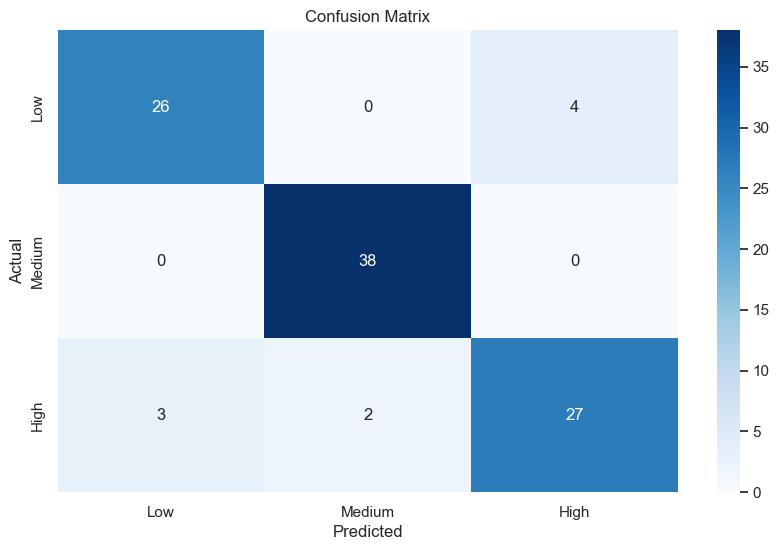

In [12]:
results = pd.DataFrame([
    compute_metrics(y_train, y_pred_train, 'Train Set (80%)'),
    compute_metrics(y_test,  y_pred_test,  'Test Set  (20%)'),
]).set_index('Set').round(4)

print(results.to_string())

cm = (confusion_matrix(y_test, y_pred_test))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()